In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Load all CSVs
csv_files = sorted(glob.glob('./*/*.csv'))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Total rows: 627,751
Columns: ['tweetid', 'userid', 'screen_name', 'date', 'lang', 'location', 'description', 'place_id', 'place_url', 'place_type', 'place_name', 'place_full_name', 'place_country_code', 'place_country', 'place_bounding_box', 'text', 'extended', 'coord', 'reply_userid', 'reply_screen', 'reply_statusid', 'tweet_type', 'friends_count', 'listed_count', 'followers_count', 'favourites_count', 'statuses_count', 'verified', 'hashtag', 'urls_list', 'profile_pic_url', 'profile_banner_url', 'display_name', 'date_first_tweet', 'account_creation_date', 'rt_urls_list', 'mentionid', 'mentionsn', 'rt_screen', 'rt_userid', 'rt_user_description', 'rt_text', 'rt_hashtag', 'rt_qtd_count', 'rt_rt_count', 'rt_reply_count', 'rt_fav_count', 'rt_tweetid', 'rt_location', 'qtd_screen', 'qtd_userid', 'qtd_user_description', 'qtd_text', 'qtd_hashtag', 'qtd_qtd_count', 'qtd_rt_count', 'qtd_reply_count', 'qtd_fav_count', 'qtd_tweetid', 'qtd_urls_list', 'qtd_location', 'sent_vader', 'token', 'media_u

## Basic stats

In [19]:
print(f"Unique users: {df['userid'].nunique():,}")
print(f"Unique tweets: {df['tweetid'].nunique():,}")
print(f"\nTweet types:")
print(df['tweet_type'].value_counts())
print(f"\nLanguages (top 10):")
print(df['lang'].value_counts(1).head(10))

Unique users: 529,213
Unique tweets: 80,149

Tweet types:
tweet_type
retweeted_tweet_without_comment    47184
quoted_tweet                       17401
reply                              11541
original                            4119
[]                                     1
Name: count, dtype: int64

Languages (top 10):
lang
en     0.892506
qme    0.050096
qht    0.019116
und    0.008424
in     0.008088
fr     0.005570
es     0.004785
art    0.002517
zxx    0.002094
th     0.001159
Name: proportion, dtype: float64


## Potential label columns

In [20]:
label_candidates = ['state', 'country', 'verified', 'lang', 'norm_country']
for col in label_candidates:
    if col in df.columns:
        n_unique = df[col].nunique()
        n_labeled = df[col].notna().sum()
        pct = 100 * n_labeled / len(df)
        print(f"{col:20s}  unique={n_unique:4d}  labeled={n_labeled:,} ({pct:.1f}%)")

state                 unique=  51  labeled=26,989 (4.3%)
country               unique= 109  labeled=34,749 (5.5%)
verified              unique=   5  labeled=80,246 (12.8%)
lang                  unique=  40  labeled=80,246 (12.8%)
norm_country          unique= 100  labeled=34,749 (5.5%)


## State distribution

In [21]:
# Per-user (not per-tweet)
user_df = df.groupby('userid').agg(
    state=('state', 'first'),
    verified=('verified', 'first'),
    followers=('followers_count', 'first'),
    friends=('friends_count', 'first'),
    statuses=('statuses_count', 'first'),
    tweet_count=('tweetid', 'count'),
).reset_index()
print(f"Total users: {len(user_df):,}")
print(f"Users with state: {user_df['state'].notna().sum():,} ({100*user_df['state'].notna().mean():.1f}%)")

state_counts = user_df['state'].value_counts(1)
print(f"\nStates: {len(state_counts)}")
print(state_counts[:15])

Total users: 529,213
Users with state: 16,383 (3.1%)

States: 51
state
CA    0.133553
FL    0.084905
TX    0.082219
NY    0.072941
PA    0.038516
AZ    0.034304
IL    0.033999
NC    0.031862
OH    0.031618
MI    0.029238
GA    0.026308
CO    0.025819
MA    0.025392
VA    0.024049
NJ    0.022645
Name: proportion, dtype: float64


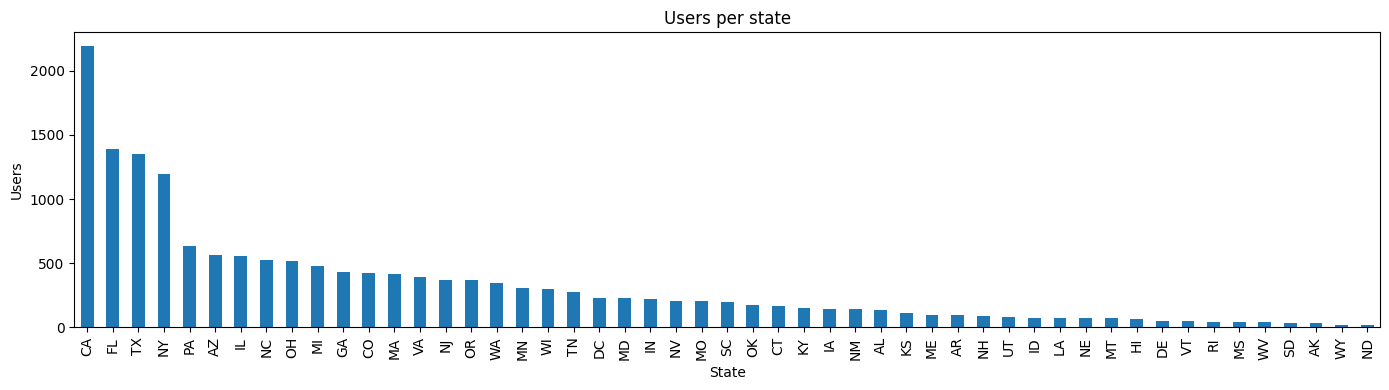

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
state_counts.plot(kind='bar', ax=ax)
ax.set_title('Users per state')
ax.set_xlabel('State')
ax.set_ylabel('Users')
plt.tight_layout()
plt.show()

## Verified users

In [23]:
user_df['verified'] = user_df['verified'].astype(bool)
verified = user_df['verified'].value_counts(1)
print(verified)
print(f"\nVerified rate: {100 * (user_df['verified'] == True).mean():.2f}%")

verified
False    0.985395
True     0.014605
Name: proportion, dtype: float64

Verified rate: 1.46%


## Follower count distribution

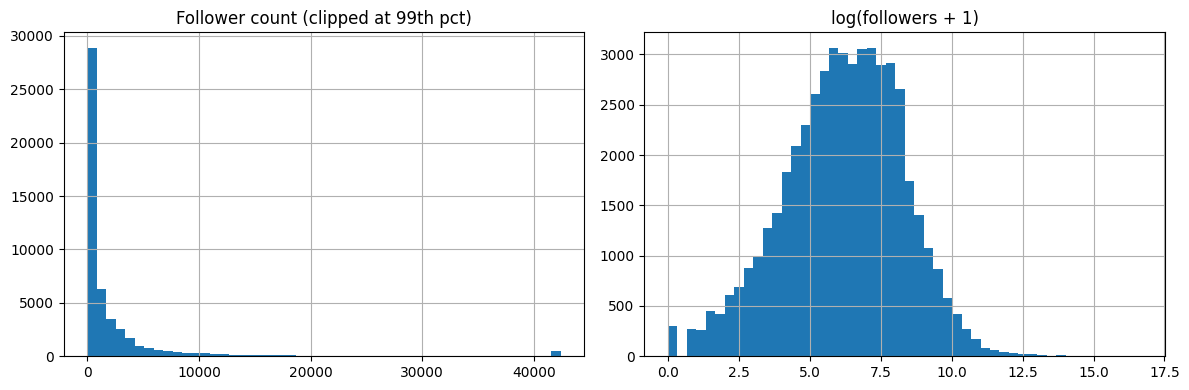

count    4.967500e+04
mean     5.119157e+03
std      1.264435e+05
min      0.000000e+00
25%      1.220000e+02
50%      5.400000e+02
75%      2.158000e+03
max      1.774862e+07
Name: followers, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_df['followers'].clip(upper=user_df['followers'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('Follower count (clipped at 99th pct)')
np.log1p(user_df['followers']).hist(bins=50, ax=axes[1])
axes[1].set_title('log(followers + 1)')
plt.tight_layout()
plt.show()

print(user_df['followers'].describe())

## Candidate labels: which ones have enough class balance?

In [30]:
# Influencer tier (log follower buckets) - could be a good transfer label
user_df['follower_tier'] = pd.qcut(np.log1p(user_df['followers']), q=5, labels=['nano','micro','mid','macro','mega'])
print("Follower tier distribution:")
print(user_df['follower_tier'].value_counts())

# Activity tier
# user_df['activity_tier'] = pd.qcut(user_df['tweet_count'], q=3, labels=['low','medium','high'])
user_df['activity_tier'] = pd.qcut(user_df['tweet_count'], q=3, labels=False, duplicates='drop')
print("\nActivity tier distribution:")
print(user_df['activity_tier'].value_counts())

Follower tier distribution:
follower_tier
nano     9996
mega     9932
macro    9930
mid      9923
micro    9894
Name: count, dtype: int64

Activity tier distribution:
activity_tier
0    529213
Name: count, dtype: int64


## Sentiment distribution by state (does state correlate with sentiment?)

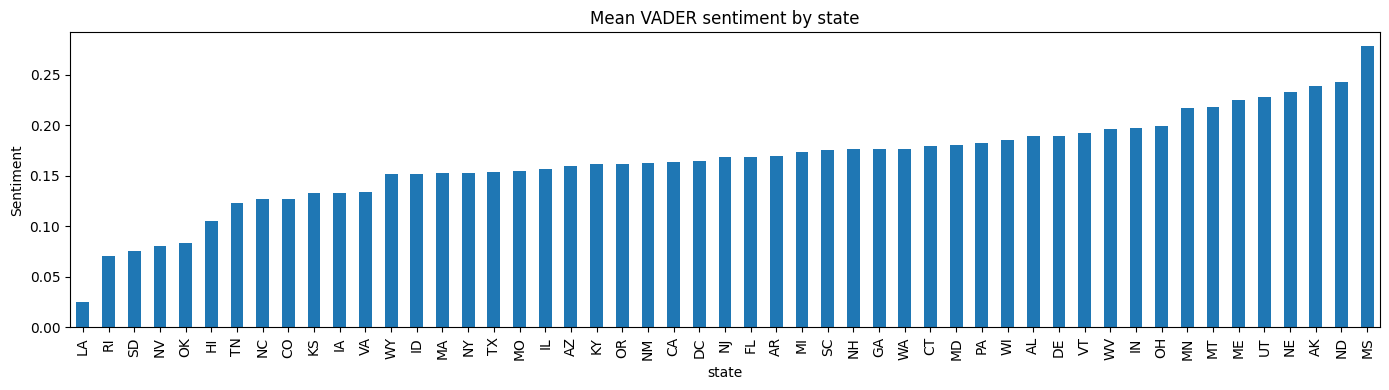

In [25]:
if 'sent_vader' in df.columns:
    state_sentiment = df[df['state'].notna()].groupby('state')['sent_vader'].mean().sort_values()
    fig, ax = plt.subplots(figsize=(14, 4))
    state_sentiment.plot(kind='bar', ax=ax)
    ax.set_title('Mean VADER sentiment by state')
    ax.set_ylabel('Sentiment')
    plt.tight_layout()
    plt.show()

## Graph stats (from graph_data.pt)

In [28]:
import torch
g = torch.load('graph/graph_data.pt', map_location='cpu')
print("Keys:", list(g.keys()))
print(f"Nodes: {g['x'].shape[0]:,}  Features: {g['x'].shape[1]}")
print(f"Edges: {g['edge_index'].shape[1]:,}")
labeled = (g['y'] >= 0).sum().item()
print(f"Labeled nodes: {labeled:,} ({100*labeled/g['x'].shape[0]:.1f}%)")
print(f"Label names: {g['label_names']}")

y = g['y']
label_counts = [(g['label_names'][i], (y == i).sum().item()) for i in range(len(g['label_names']))]
label_counts.sort(key=lambda x: -x[1])
print(f"\nNodes per state (top/bottom 5):")
for name, count in label_counts[:5]:
    print(f"  {name}: {count:,}")
print("  ...")
for name, count in label_counts[-5:]:
    print(f"  {name}: {count:,}")

Keys: ['x', 'edge_index', 'user_ids', 'feature_names', 'y', 'label_names']
Nodes: 547,504  Features: 98
Edges: 1,403,367
Labeled nodes: 148,777 (27.2%)
Label names: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

Nodes per state (top/bottom 5):
  CA: 19,061
  TX: 13,985
  FL: 12,171
  NY: 11,179
  PA: 5,666
  ...
  VT: 354
  AK: 340
  SD: 318
  WY: 203
  ND: 160


## Node degree distribution

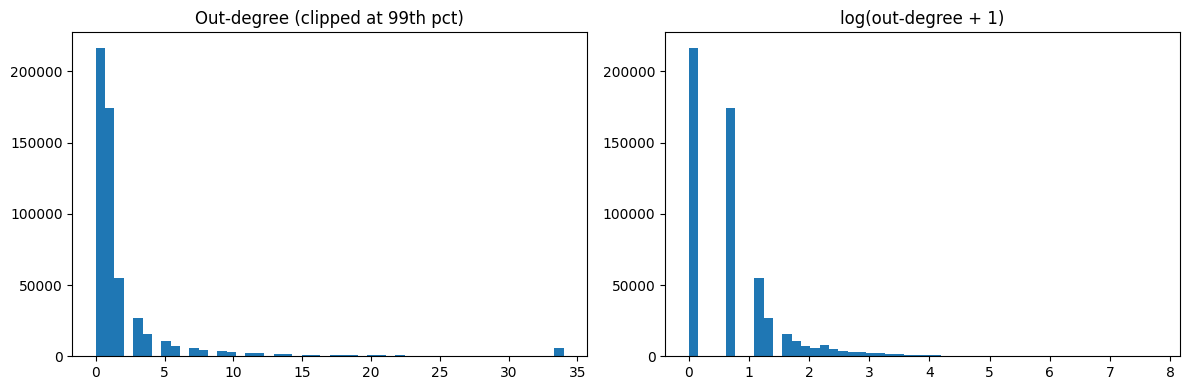

Mean degree: 2.56
Median degree: 1.00
Max degree: 2383
Isolated nodes (degree=0): 216,530


In [29]:
edge_index = g['edge_index']
degrees = torch.bincount(edge_index[0], minlength=g['x'].shape[0])
degrees_np = degrees.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(degrees_np.clip(max=int(np.percentile(degrees_np, 99))), bins=50)
axes[0].set_title('Out-degree (clipped at 99th pct)')
axes[1].hist(np.log1p(degrees_np), bins=50)
axes[1].set_title('log(out-degree + 1)')
plt.tight_layout()
plt.show()

print(f"Mean degree: {degrees_np.mean():.2f}")
print(f"Median degree: {np.median(degrees_np):.2f}")
print(f"Max degree: {degrees_np.max()}")
print(f"Isolated nodes (degree=0): {(degrees_np == 0).sum():,}")